/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6901 - loss: 0.6880 - val_accuracy: 0.7895 - val_loss: 0.6765
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7473 - loss: 0.6652 - val_accuracy: 0.7719 - val_loss: 0.6399
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7231 - loss: 0.6165 - val_accuracy: 0.7456 - val_loss: 0.5720
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7582 - loss: 0.5480 - val_accuracy: 0.7895 - val_loss: 0.4871
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8374 - loss: 0.4702 - val_accuracy: 0.8772 - val_loss: 0.3988
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8681 - loss: 0.3999 - val_accuracy: 0.8860 - val_loss: 0.3306
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8659 - loss: 0.3439 - val_accuracy: 0.9386 - val_loss: 0.2742
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8857 - loss: 0.3055 - val_accuracy: 0.9386 - v

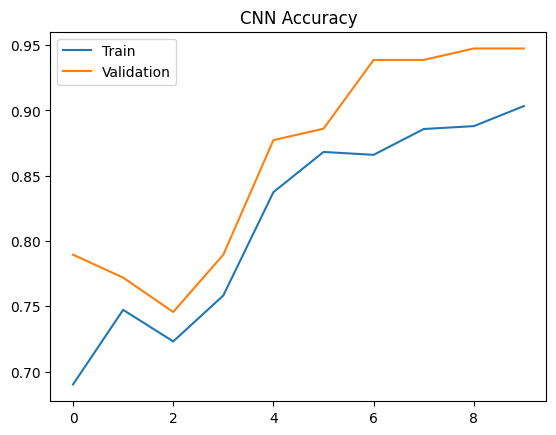

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


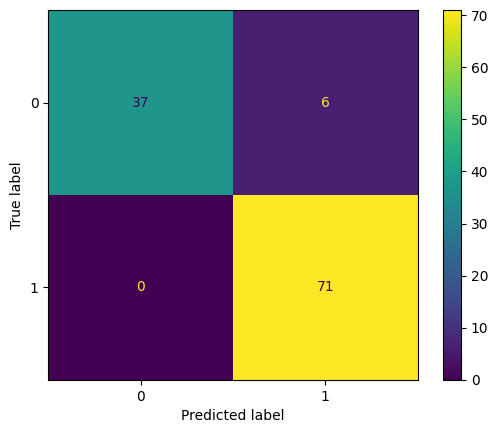

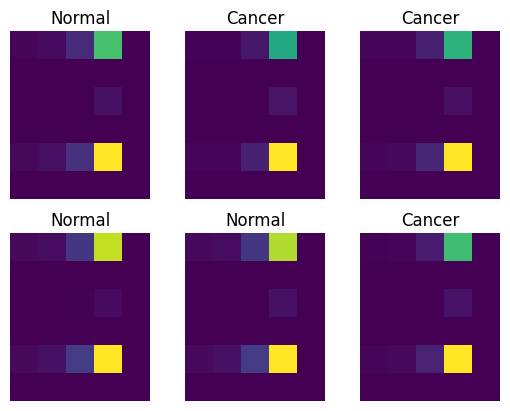

Model trained successfully
Accuracy shows model can classify cancer vs normal


In [16]:
# ================================
# Cancer CNN (One Cell, No Download)
# ================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load real cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Normalize
X = (X - X.min()) / (X.max() - X.min())

# Convert tabular data to image-like (reshape to 6x5)
X = X.reshape(-1, 6, 5, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(6,5,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Visualize "image-like" cancer data
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[i].reshape(6,5), cmap='viridis')
    plt.title("Cancer" if y_test[i]==0 else "Normal")
    plt.axis("off")
plt.show()

print("Model trained successfully")
print("Accuracy shows model can classify cancer vs normal")